# 04 Results and Visualization

This notebook summarizes model behavior and presents performance-focused visualizations.

Expected outputs:
- Parity and residual diagnostics
- Tuned model outer-fold performance summary
- UMAP-based structure-property visualization

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Standalone setup: rebuild core modeling artifacts needed by downstream result cells
df = pd.read_csv('battery_stats_cycles_001_750_mapped.csv')
df = df[df['discharge_energy_wh'] > 0.5].copy()

def charge_cutoff_to_numeric(val):
    if pd.isna(val):
        return None
    denominator = int(str(val).split('/')[1])
    return 1.0 / denominator

df['charge_cutoff_numeric'] = df['charge_cutoff'].apply(charge_cutoff_to_numeric)
df_clean = df.copy()
model_features = ['cycle_number', 'voltage_v', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

# Drop rows missing any required feature, target, or group label
required_cols = model_features + ['discharge_energy_wh', 'sample_number']
df_clean = df_clean.dropna(subset=required_cols).reset_index(drop=True)
print(f'Rows after dropping NaNs: {len(df_clean):,}')

X_all = df_clean[model_features].values
y_all = df_clean['discharge_energy_wh'].values
groups = df_clean['sample_number'].values

# First fold artifacts for UMAP/result cells
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X_all, y_all, groups))
train_idx, test_idx = folds[0]
X_train, X_test = X_all[train_idx], X_all[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]
groups_train = groups[train_idx]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42))
])

r2_group = cross_val_score(pipe, X_all, y_all, cv=GroupKFold(5), groups=groups, scoring='r2')
mae_group = cross_val_score(pipe, X_all, y_all, cv=GroupKFold(5), groups=groups, scoring='neg_mean_absolute_error')

param_dist = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_leaf': [1, 2, 5],
    'rf__max_features': ['sqrt', 'log2', 0.3],
}
rscv = RandomizedSearchCV(
    pipe, param_dist, n_iter=15, cv=GroupKFold(n_splits=5),
    scoring='r2', n_jobs=-1, random_state=42, verbose=0
)
rscv.fit(X_train, y_train, groups=groups_train)
best_model = rscv

# Rebuild cross-validated predictions used by parity/residual plots
all_y_test = []
all_y_pred = []
for tr_idx, te_idx in GroupKFold(n_splits=5).split(X_all, y_all, groups):
    fold_scaler = StandardScaler()
    X_tr = fold_scaler.fit_transform(X_all[tr_idx])
    X_te = fold_scaler.transform(X_all[te_idx])
    model = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model.fit(X_tr, y_all[tr_idx])
    preds = model.predict(X_te)
    all_y_test.append(y_all[te_idx])
    all_y_pred.append(preds)
all_y_test = np.concatenate(all_y_test)
all_y_pred = np.concatenate(all_y_pred)

print('Standalone setup complete:', len(df_clean), 'rows')

Rows after dropping NaNs: 91,999
Standalone setup complete: 91999 rows


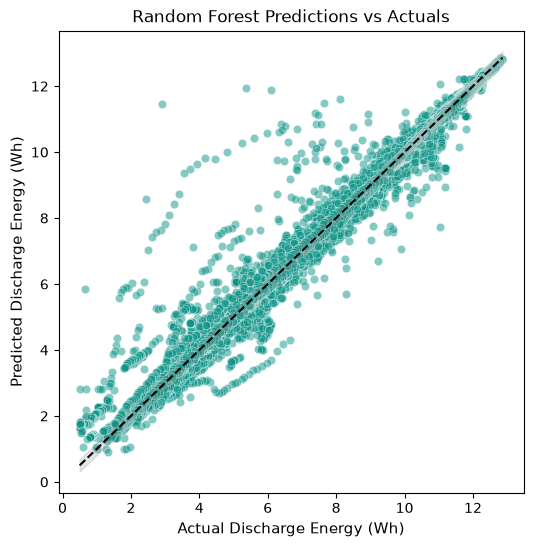

Residual standard deviation: 0.188 Wh
Mean absolute error: 0.068 Wh


In [3]:
residuals = all_y_pred - all_y_test
residual_std = np.std(residuals)
mae = np.mean(np.abs(residuals))
fig,ax = plt.subplots(figsize=(6, 6))

ax.scatter(all_y_test, all_y_pred, alpha=0.5, color='#0D9488', edgecolor='white', linewidth=0.4)
lims = [
    min(all_y_test.min(), all_y_pred.min()),
    max(all_y_test.max(), all_y_pred.max())
]
ax.fill_between(lims, lims - residual_std, lims + residual_std,
                alpha=0.2, color='grey', label=f'±MAE (MAE={mae:.3f} Wh)')

ax.set_xlabel('Actual Discharge Energy (Wh)', fontsize=11)
ax.set_ylabel('Predicted Discharge Energy (Wh)', fontsize=11)
ax.set_title('Random Forest Predictions vs Actuals', fontsize=12)
plt.plot(lims, lims, 'k--')
plt.show()
print(f"Residual standard deviation: {residual_std:.3f} Wh")
print(f"Mean absolute error: {mae:.3f} Wh")

In [4]:
residuals = all_y_pred - all_y_test
mae = np.mean(np.abs(residuals))

# Calculate percentage within ±MAE
pct_within_mae = 100 * np.mean(np.abs(residuals) <= mae)
print(f"MAE: {mae:.3f} Wh")
print(f"Percentage of residuals within ±MAE: {pct_within_mae:.1f}%")

# Also check ±1 std for reference
residual_std = np.std(residuals)
pct_within_1std = 100 * np.mean(np.abs(residuals) <= residual_std)
print(f"Residual Std: {residual_std:.3f} Wh")
print(f"Percentage of residuals within ±1 std: {pct_within_1std:.1f}%")

MAE: 0.068 Wh
Percentage of residuals within ±MAE: 74.9%
Residual Std: 0.188 Wh
Percentage of residuals within ±1 std: 94.8%


In [5]:
#use the model tuned on one fold and evaluate it across all folds using GroupKFold cross validation. This will give a more robust estimate of the model's performance and help to avoid overfitting to a single fold.
from sklearn.base import clone

outer_gkf = GroupKFold(n_splits=5)

tuned_rows = []

for fold_num, (train_idx, test_idx) in enumerate(
    outer_gkf.split(X_all, y_all, groups), start=1
):
    X_train_outer, X_test_outer = X_all[train_idx], X_all[test_idx]
    y_train_outer, y_test_outer = y_all[train_idx], y_all[test_idx]
    groups_train_outer = groups[train_idx]

    # Clone the best estimator and fit on this fold's training data
    fold_model = clone(best_model.best_estimator_)
    fold_model.fit(X_train_outer, y_train_outer)
    y_pred_tuned_outer = fold_model.predict(X_test_outer)

    tuned_rows.append({
        "Fold": fold_num,
        "R2": r2_score(y_test_outer, y_pred_tuned_outer),
        "MAE": mean_absolute_error(y_test_outer, y_pred_tuned_outer),
        "RMSE": np.sqrt(mean_squared_error(y_test_outer, y_pred_tuned_outer))
    })


tuned_df = pd.DataFrame(tuned_rows)
tuned_mean_r2,tuned_std = tuned_df['R2'].aggregate(['mean', 'std'])
print(tuned_df)
print(f"\nTuned RF (RandomizedSearchCV) - GroupKFold 5-fold CV: R2 = {tuned_mean_r2:.3f} ± {tuned_std:.3f}")

   Fold        R2       MAE      RMSE
0     1  0.990281  0.073779  0.207945
1     2  0.994772  0.068001  0.162638
2     3  0.982365  0.071542  0.282564
3     4  0.987333  0.073342  0.255757
4     5  0.994996  0.060805  0.157396

Tuned RF (RandomizedSearchCV) - GroupKFold 5-fold CV: R2 = 0.990 ± 0.005


In [6]:
#PCA and UMAP dimensionality reduction on the dataset to visualize the data in 2D space and see if there are any patterns or clusters based on the features.
#done on one fold 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap


pca10 = PCA(n_components=5, random_state=42)
X_train_pca = pca10.fit_transform(X_train_scaled)

print(f"PCA-10 cumulative variance: {pca10.explained_variance_ratio_.sum():.1%}")

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
embedding_train = reducer.fit_transform(X_train_pca)

np.save('umap_train.npy', embedding_train)
print(f"Training embedding shape: {embedding_train.shape}")


PCA-10 cumulative variance: 100.0%


c:\Users\RXT0TKQ\AppData\Local\miniconda3\miniconda\envs\matds\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Training embedding shape: (73599, 2)


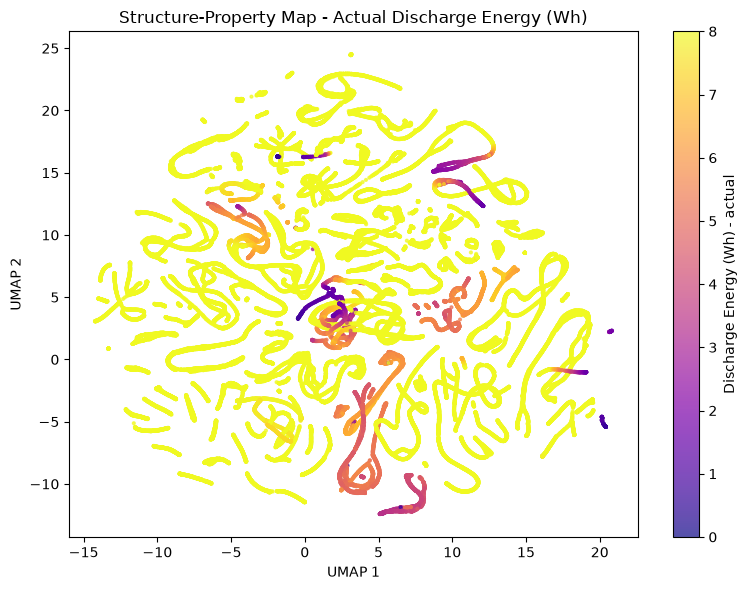

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(embedding_train[:,0], embedding_train[:,1],
                c=y_train, cmap='plasma', vmin=0, vmax=8, s=4, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Discharge Energy (Wh) - actual')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('Structure-Property Map - Actual Discharge Energy (Wh)', fontsize=12)
plt.tight_layout()
plt.savefig('DE_umap_actual.png', dpi=150)
plt.show()

In [8]:
# Feature ablation: Test model performance WITHOUT voltage
# to determine if voltage is doing all the prediction work

model_features_no_voltage = ['cycle_number', 'temperature_c', 'discharge_rate', 'charge_cutoff_numeric']

X_all_no_v = df_clean[model_features_no_voltage].values
y_all_same = df_clean['discharge_energy_wh'].values

r2_no_voltage = cross_val_score(pipe, X_all_no_v, y_all_same,
                                cv=GroupKFold(5), groups=groups, scoring="r2")

mae_no_voltage = cross_val_score(pipe, X_all_no_v, y_all_same,
                                 cv=GroupKFold(5), groups=groups, scoring="neg_mean_absolute_error")

print("=" * 60)
print("Feature Ablation Study: Model Performance WITHOUT Voltage")
print("=" * 60)
print(f"With voltage    - R²: {r2_group.mean():.3f} ± {r2_group.std():.3f}  |  MAE: {-mae_group.mean():.3f} ± {-mae_group.std():.3f}")
print(f"Without voltage - R²: {r2_no_voltage.mean():.3f} ± {r2_no_voltage.std():.3f}  |  MAE: {-mae_no_voltage.mean():.3f} ± {-mae_no_voltage.std():.3f}")
print(f"\nR² Drop: {r2_group.mean() - r2_no_voltage.mean():.3f}")
print("=" * 60)

Feature Ablation Study: Model Performance WITHOUT Voltage
With voltage    - R²: 0.993 ± 0.003  |  MAE: 0.068 ± -0.005
Without voltage - R²: 0.923 ± 0.042  |  MAE: 0.192 ± -0.015

R² Drop: 0.069
